# Assignment 4

Deadline: 13.05.2026, 12:00 CET

<Add your name, student-id and emal address>

In [3]:
# Standard library imports
import os
import sys

# Third party imports
import numpy as np
import pandas as pd
import statsmodels.api as sm    # for regression analysis in 1.c) (or any other regression library you prefer)

# Add the project root directory to Python path
project_root = os.path.dirname(os.path.dirname(os.getcwd()))  # Change this path if needed
src_path = os.path.join(project_root, 'qpmwp-course\\src')
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import (
    load_pickle,
    load_data_spi,
    align_market_data_with_jkp_data,
)
from optimization.optimization import PercentilePortfolio
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_min_volume,
    bibfn_selection_jkp_data_scores,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_scores,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest

## Constants

In [4]:
PATH_TO_DATA = 'C:/Users/User/OneDrive/Documents/QPMwP/Data/'     # <change this to your path to data>
SAVE_PATH = 'C:/Users/User/OneDrive/Documents/QPMwP/2026/Code/'   # <change this to your path where you want to store the backtest>

## Load data and initialize BacktestData class
- market data (from parquet file)
- jkp data (from parquet file)
- swiss performance index, SPI (from csv file)

In [5]:
# Load market and jkp data from parquet files
market_data = pd.read_parquet(path = f'{PATH_TO_DATA}market_data.parquet')
jkp_data = pd.read_parquet(path = f'{PATH_TO_DATA}jkp_data.parquet')
spi = load_data_spi(path='../data/')

# Align market data with jkp data
market_data_ffill, jkp_data = align_market_data_with_jkp_data(market_data=market_data, jkp_data=jkp_data)

# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
data = BacktestData()
data.market_data = market_data_ffill  # notice that we use the forward filled market data here
data.jkp_data = jkp_data
data.bm_series = spi

## Define a grid or rebalancing dates

In [6]:
n_month = 3 # We want to rebalance every n_month months
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data.index.get_level_values('date').min()
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
rebdates = [date for date in rebdates if date > '2002-01-01']
rebdates

['2002-01-31',
 '2002-04-30',
 '2002-07-31',
 '2002-10-31',
 '2003-01-31',
 '2003-04-30',
 '2003-07-31',
 '2003-10-31',
 '2004-01-31',
 '2004-04-30',
 '2004-07-31',
 '2004-10-31',
 '2005-01-31',
 '2005-04-30',
 '2005-07-31',
 '2005-10-31',
 '2006-01-31',
 '2006-04-30',
 '2006-07-31',
 '2006-10-31',
 '2007-01-31',
 '2007-04-30',
 '2007-07-31',
 '2007-10-31',
 '2008-01-31',
 '2008-04-30',
 '2008-07-31',
 '2008-10-31',
 '2009-01-31',
 '2009-04-30',
 '2009-07-31',
 '2009-10-31',
 '2010-01-31',
 '2010-04-30',
 '2010-07-31',
 '2010-10-31',
 '2011-01-31',
 '2011-04-30',
 '2011-07-31',
 '2011-10-31',
 '2012-01-31',
 '2012-04-30',
 '2012-07-31',
 '2012-10-31',
 '2013-01-31',
 '2013-04-30',
 '2013-07-31',
 '2013-10-31',
 '2014-01-31',
 '2014-04-30',
 '2014-07-31',
 '2014-10-31',
 '2015-01-31',
 '2015-04-30',
 '2015-07-31',
 '2015-10-31',
 '2016-01-31',
 '2016-04-30',
 '2016-07-31',
 '2016-10-31',
 '2017-01-31',
 '2017-04-30',
 '2017-07-31',
 '2017-10-31',
 '2018-01-31',
 '2018-04-30',
 '2018-07-

## 1. a) Define the key data fields that characterize a factor theme

- Beside the pre-defined fields, choose three factor themes from table 9 of the Global Factor Data Documentation (See https://jkpfactors-data.s3.amazonaws.com/documents/Documentation.pdf, Section 10.) and add the individual fields.

**(2 points)**

In [7]:

JKP_FIELDS_ACCRUALS = [
    'cowc_gr1a',
    'oaccruals_at',
    'oaccruals_ni',
    # 'seas_16_20_na',
    'taccruals_at',
    'taccruals_ni',
]

JKP_FIELDS_DEBT_ISSUANCE = [
    'capex_abn',
    'debt_gr3',
    'fnl_gr1a',
    'ncol_gr1a',
    'nfna_gr1a',
    'ni_ar1',
    'noa_at',
]

JKP_FIELDS_INVESTMENT = [
    'aliq_at',
    'at_gr1',
    'be_gr1a',
    'capx_gr1',
    'capx_gr2',
    'capx_gr3',
    'coa_gr1a',
    'col_gr1a',
    'emp_gr1',
    'inv_gr1',
    'inv_gr1a',
    'lnoa_gr1a',
    'mispricing_mgmt',
    'ncoa_gr1a',
    'nncoa_gr1a',
    'noa_gr1a',
    'ppeinv_gr1a',
    'ret_60_12',
    'sale_gr1',
    'sale_gr3',
    'saleq_gr1',
    'seas_2_5na',
]

JKP_FIELDS_LOW_LEVERAGE = [
    'age',
    'aliq_mat',
    'at_be',
    'bidaskhl_21d',
    'cash_at',
    'netdebt_me',
    'ni_ivol',
    'rd_sale',
    'rd5_at',
    'tangibility',
    'z_score',
]

JKP_FIELDS_LOW_RISK = [
    'beta_60m',
    'beta_dimson_21d',
    'betabab_1260d',
    'betadown_252d',
    'earnings_variability',
    'ivol_capm_21d',
    'ivol_capm_252d',
    'ivol_ff3_21d',
    'ivol_hxz4_21d',
    'rmax1_21d',
    'rmax5_21d',
    'rvol_21d',
    'seas_6_10na',
    'turnover_126d',
    'zero_trades_21d',
    'zero_trades_126d',
    'zero_trades_252d',
]

JKP_FIELDS_MOMENTUM = [
    'prc_highprc_252d',
    'resff3_6_1',
    'resff3_12_1',
    'ret_3_1',
    'ret_6_1',
    'ret_9_1',
    'ret_12_1',
    'seas_1_1na',
]

JKP_FIELDS_PROFIT_GROWTH = [
    'dsale_dinv',
    'dsale_drec',
    'dsale_dsga',
    'niq_at_chg1',
    'niq_be_chg1',
    'niq_su',
    'ocf_at_chg1',
    'ret_12_7',
    'sale_emp_gr1',
    'saleq_su',
    'seas_1_1an',
    'tax_gr1a',
]

JKP_FIELDS_PROFITABILITY = [
    'dolvol_var_126d',
    'ebit_bev',
    'ebit_sale',
    'f_score',
    'ni_be',
    'niq_be',
    'o_score',
    'ocf_at',
    'ope_be',
    'ope_bel1',
    'turnover_var_126d',
]

JKP_FIELDS_QUALITY = [
    'at_turnover',
    'cop_at',
    'cop_atl1',
    'dgp_dsale',
    'gp_at',
    'gp_atl1',
    'mispricing_perf',
    'ni_inc8q',
    'niq_at',
    'op_at',
    'op_atl1',
    'opex_at',
    'qmj_prof',
    'qmj_growth',
    'qmj_safety',
    'sale_bev',
]

JKP_FIELDS_SEASONALITY = [
    'corr_1260d',
    'coskew_21d',
    'dbnetis_at',
    'kz_index',
    'lti_gr1a',
    'pi_nix',
    'seas_2_5an',
    'seas_6_10an',
    'seas_11_15an',
    'seas_16_20an',
    'sti_gr1a',
]

JKP_FIELDS_SEASONALITY = [
    'corr_1260d',
    'coskew_21d',
    'dbnetis_at',
    'lti_gr1a',

]

JKP_FIELDS_SIZE = [
    'ami_126d',
    'dolvol_126d',
    'market_equity',
    'prc',
    'rd_me'
]

JKP_FIELDS_SHORT_TERM_REVERSAL = [
    'iskew_capm_21d',
    'iskew_ff3_21d',
    'iskew_hxz4_21d',
    'ret_1_0',
    'rmax5_rvol_21d',
    'rskew_21d',
]

JKP_FIELDS_VALUE = [
    'at_me',
    'be_me',
    'bev_mev',
    'chcsho_12m',
    'debt_me',
    'div12m_me',
    'ebitda_mev',
    'eq_dur',
    'eqnetis_at',
    'eqnpo_12m',
    'eqnpo_me',
    'fcf_me',
    'ival_me',
    'netis_at',
    'ni_me',
    'ocf_me',
    'sale_me',
]


JKP_FIELDS = {
    'accruals': JKP_FIELDS_ACCRUALS,
    'debt_issuance': JKP_FIELDS_DEBT_ISSUANCE,
    'investment': JKP_FIELDS_INVESTMENT,
    # 'low_leverage': JKP_FIELDS_LOW_LEVERAGE,
    'low_risk': JKP_FIELDS_LOW_RISK,
    'momentum': JKP_FIELDS_MOMENTUM,
    'profit_growth': JKP_FIELDS_PROFIT_GROWTH,
    'profitability': JKP_FIELDS_PROFITABILITY,
    'quality': JKP_FIELDS_QUALITY,
    'seasonality': JKP_FIELDS_SEASONALITY,
    'size': JKP_FIELDS_SIZE,
    'short_term_reversal': JKP_FIELDS_SHORT_TERM_REVERSAL,
    'value': JKP_FIELDS_VALUE,
}



# Sign flip needed so that higher = better.
SIGN_FLIP_REQUIRED = [

    # Accruals
    'cowc_gr1a',
    'oaccruals_at',
    'oaccruals_ni',
    'taccruals_at',
    'taccruals_ni',

    # Dept Issuance
    'capex_abn',
    'debt_gr3',
    'fnl_gr1a',
    'ncol_gr1a',
    'noa_at',

    # Investment
    'aliq_at',
    'at_gr1',
    'be_gr1a',
    'capx_gr1',
    'capx_gr2',
    'capx_gr3',
    'coa_gr1a',
    'col_gr1a',
    'emp_gr1',
    'inv_gr1',
    'inv_gr1a',
    'lnoa_gr1a',
    'ncoa_gr1a',
    'nncoa_gr1a',
    'noa_gr1a',
    'ppeinv_gr1a',
    'ret_60_12',
    'sale_gr1',
    'sale_gr3',
    'saleq_gr1',
    'seas_2_5na',

    # Low Leverage
    'age',
    'aliq_mat',
    'at_be',
    'netdebt_me',

    # Low Risk
    'beta_60m',
    'beta_dimson_21d',
    'betabab_1260d',
    'betadown_252d',
    'earnings_variability',
    'ivol_capm_21d',
    'ivol_capm_252d',
    'ivol_ff3_21d',
    'ivol_hxz4_21d',
    'rmax1_21d',
    'rmax5_21d',
    'rvol_21d',
    'seas_6_10na',
    'turnover_126d',

    # Profit growth
    'dsale_drec',

    # Profitability
    'dolvol_var_126d',
    'o_score',
    'turnover_var_126d',

    # Seasonality
    'corr_1260d',
    'coskew_21d',
    'dbnetis_at',
    'lti_gr1a',

    # Size
    'dolvol_126d',
    'market_equity',
    'prc',

    # Short term reversal
    'iskew_capm_21d',
    'iskew_ff3_21d',
    'iskew_hxz4_21d',
    'ret_1_0',
    'rmax5_rvol_21d',
    'rskew_21d',

    # Value
    'chcsho_12m',
    'eq_dur',
    'eqnetis_at',
    'netis_at',
]


## 1. b) Factor series for each factor theme.

- For each factor theme, run a backtest for the top‑quintile portfolio and a second backtest for the bottom‑quintile portfolio.
Simulate both return streams, and define the factor series as a long-short portfolio going long the top quintile portfolio and going short the bottom quintile portfolio.

- Plot the cumulative returns of the top quintile portfolio, the bottom quintile portfolio, the long-short factor portfolio, and the benchmark series.

**(8 points)**

In [8]:
# Validate that all required fields are present in the JKP dataset.
# Raises immediately so a missing field is never silently ignored.

for theme_name, fields in JKP_FIELDS.items():
    missing = [f for f in fields if f not in data.jkp_data.columns]
    if missing:
        raise ValueError(
            f"Theme '{theme_name}' is missing fields: {missing}. "
            "Check your JKP data version or field names."
        )
    else:
        print(f"{theme_name}: all fields OK")

accruals: all fields OK
debt_issuance: all fields OK
investment: all fields OK
low_risk: all fields OK
momentum: all fields OK
profit_growth: all fields OK
profitability: all fields OK
quality: all fields OK
seasonality: all fields OK
size: all fields OK
short_term_reversal: all fields OK
value: all fields OK


In [9]:
# Apply sign flip
for field in SIGN_FLIP_REQUIRED:
    if field in jkp_data.columns:
        data.jkp_data[field] = -data.jkp_data[field]

In [10]:
# Standardize scores so that averaging over fields is meaningful.
# We transform the raw scores to ranks and then standardize the ranks to have mean 0 and std 1 (z-scores)

data.jkp_data = data.jkp_data.groupby('date').transform(lambda x: x.rank())  # rank transformation to [1,N]
data.jkp_data = data.jkp_data.groupby('date').transform(lambda x: (x - x.mean()) / x.std())  # standardize to z-scores

# data.jkp_data.loc['2023-06-30'].describe()
# data.jkp_data.loc['2023-06-30'].plot(kind='density')

In [13]:
# Running the backtests

failures = []
for factor_theme, fields in JKP_FIELDS.items():

    try:

        # Instantiate the backtest service with the selection and optimization item builders
        bs = BacktestService(
            data=data,
            selection_item_builders={
                'min_volume': SelectionItemBuilder(
                    bibfn=bibfn_selection_min_volume,
                    width=365,
                    min_volume=500_000,
                    agg_fn=np.median,
                ),
                'jkp_data_scores': SelectionItemBuilder(
                    bibfn=bibfn_selection_jkp_data_scores,                   
                    fields=fields,
                ),
            },
            optimization_item_builders={
                'scores': OptimizationItemBuilder(
                    bibfn=bibfn_scores,
                    fields=fields,
                ),
            },
            optimization=PercentilePortfolio(
                percentile=80,
                sign='>=',
            ),
            rebdates=rebdates,
        )    

        # Instantiate the backtest object, run the backtest, and save as a pickle file
        bt_tqp = Backtest()
        bt_tqp.run(bs=bs)

        # Save the backtest object as a pickle file
        bt_tqp.save(
            path=SAVE_PATH,
            filename=f'ass_4_tqp_{factor_theme}.pickle'
        )

        # Adjust the optimization so that the bottom quintile portfolio is computed
        bs.optimization = PercentilePortfolio(
            percentile=20,
            sign='<=',
        )
        # Rerun the backtest ans save as pickle
        bt_bqp = Backtest()
        bt_bqp.run(bs=bs)
        bt_bqp.save(
            path=SAVE_PATH,
            filename=f'ass_4_bqp_{factor_theme}.pickle'
        )

    except:
        failures.append(factor_theme)


print(failures)
    

Rebalancing date: 2002-01-31
Rebalancing date: 2002-04-30
Rebalancing date: 2002-07-31
Rebalancing date: 2002-10-31
Rebalancing date: 2003-01-31
Rebalancing date: 2003-04-30
Rebalancing date: 2003-07-31
Rebalancing date: 2003-10-31
Rebalancing date: 2004-01-31
Rebalancing date: 2004-04-30
Rebalancing date: 2004-07-31
Rebalancing date: 2004-10-31
Rebalancing date: 2005-01-31
Rebalancing date: 2005-04-30
Rebalancing date: 2005-07-31
Rebalancing date: 2005-10-31
Rebalancing date: 2006-01-31
Rebalancing date: 2006-04-30
Rebalancing date: 2006-07-31
Rebalancing date: 2006-10-31
Rebalancing date: 2007-01-31
Rebalancing date: 2007-04-30
Rebalancing date: 2007-07-31
Rebalancing date: 2007-10-31
Rebalancing date: 2008-01-31
Rebalancing date: 2008-04-30
Rebalancing date: 2008-07-31
Rebalancing date: 2008-10-31
Rebalancing date: 2009-01-31
Rebalancing date: 2009-04-30
Rebalancing date: 2009-07-31
Rebalancing date: 2009-10-31
Rebalancing date: 2010-01-31
Rebalancing date: 2010-04-30
Rebalancing da

In [11]:
# Running the simulations

# Cost assumptions
fixed_costs = 0
variable_costs = 0

# Load the single stock return series
return_series = data.get_return_series(weekdays_only=False)

# Prepare output dictionaries to store the factor return series and
# top quintile return series for each factor theme
factor_return_series_dict = {}
top_quintile_return_series_dict = {}
bottom_quintile_return_series_dict = {}

for factor_theme, fields in JKP_FIELDS.items():

    if factor_theme in ['low_risk', 'profit_growth', 'short_term_reversal']:
        continue

    print(f'Factor theme: {factor_theme}')
    print(f'Fields: {fields}')

    # Load backtests from pickle
    bt_tqp = load_pickle(
        filename=f'ass_4_tqp_{factor_theme}.pickle',
        path=SAVE_PATH,
    )
    bt_bqp = load_pickle(
        filename=f'ass_4_bqp_{factor_theme}.pickle',
        path=SAVE_PATH,
    )

    # Run the simulations for both backtests
    sim_tqp = bt_tqp.strategy.simulate(
        return_series=return_series,
        fc=fixed_costs,
        vc=variable_costs
    )
    sim_bqp = bt_bqp.strategy.simulate(
        return_series=return_series,
        fc=fixed_costs,
        vc=variable_costs
    )

    # Compute the factor return series
    factor_return_series = sim_tqp - sim_bqp
    factor_return_series.name = factor_theme

    # Store the factor return series in the dictionary
    factor_return_series_dict[factor_theme] = factor_return_series
    top_quintile_return_series_dict[factor_theme] = sim_tqp
    bottom_quintile_return_series_dict[factor_theme] = sim_bqp

Factor theme: accruals
Fields: ['cowc_gr1a', 'oaccruals_at', 'oaccruals_ni', 'taccruals_at', 'taccruals_ni']
Factor theme: debt_issuance
Fields: ['capex_abn', 'debt_gr3', 'fnl_gr1a', 'ncol_gr1a', 'nfna_gr1a', 'ni_ar1', 'noa_at']
Factor theme: investment
Fields: ['aliq_at', 'at_gr1', 'be_gr1a', 'capx_gr1', 'capx_gr2', 'capx_gr3', 'coa_gr1a', 'col_gr1a', 'emp_gr1', 'inv_gr1', 'inv_gr1a', 'lnoa_gr1a', 'mispricing_mgmt', 'ncoa_gr1a', 'nncoa_gr1a', 'noa_gr1a', 'ppeinv_gr1a', 'ret_60_12', 'sale_gr1', 'sale_gr3', 'saleq_gr1', 'seas_2_5na']
Factor theme: momentum
Fields: ['prc_highprc_252d', 'resff3_6_1', 'resff3_12_1', 'ret_3_1', 'ret_6_1', 'ret_9_1', 'ret_12_1', 'seas_1_1na']
Factor theme: profitability
Fields: ['dolvol_var_126d', 'ebit_bev', 'ebit_sale', 'f_score', 'ni_be', 'niq_be', 'o_score', 'ocf_at', 'ope_be', 'ope_bel1', 'turnover_var_126d']
Factor theme: quality
Fields: ['at_turnover', 'cop_at', 'cop_atl1', 'dgp_dsale', 'gp_at', 'gp_atl1', 'mispricing_perf', 'ni_inc8q', 'niq_at', 'op_

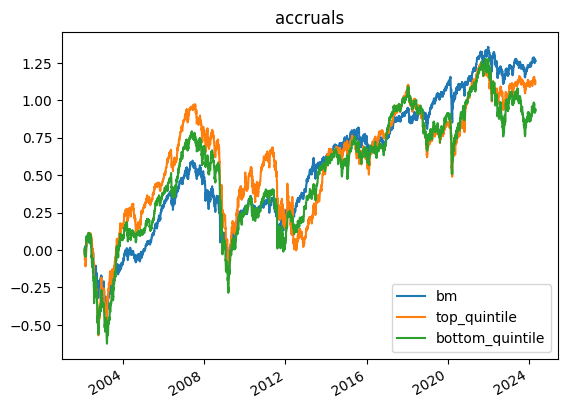

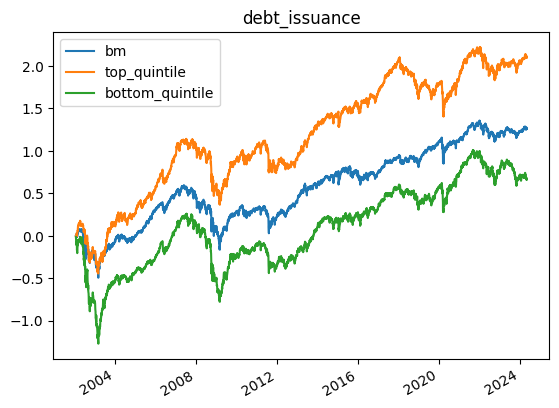

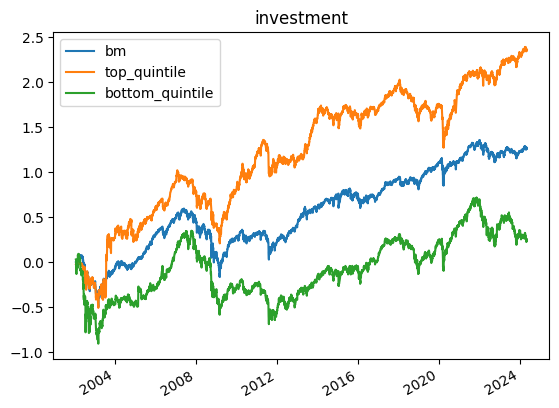

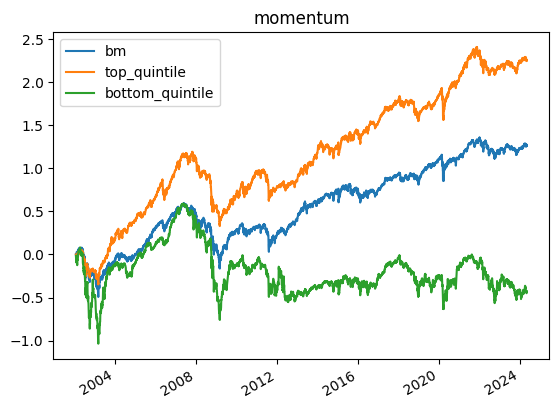

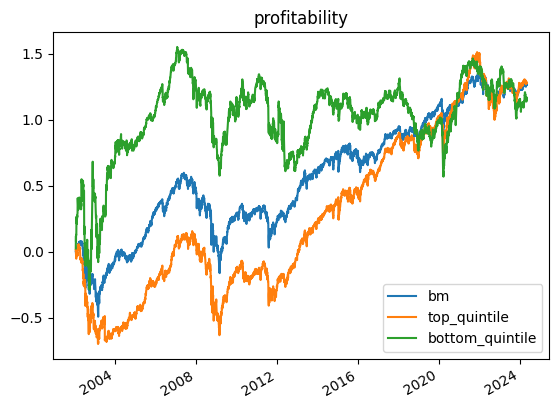

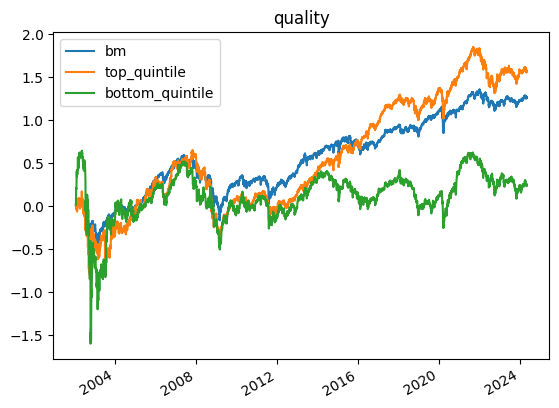

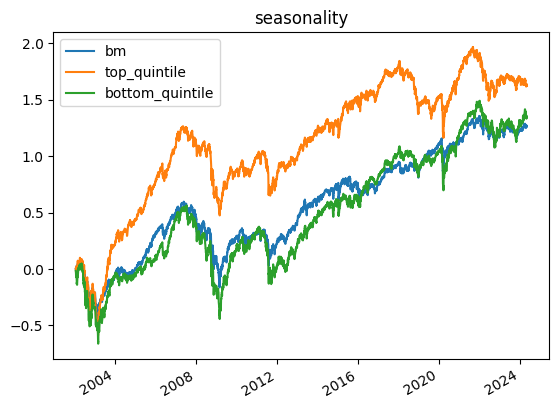

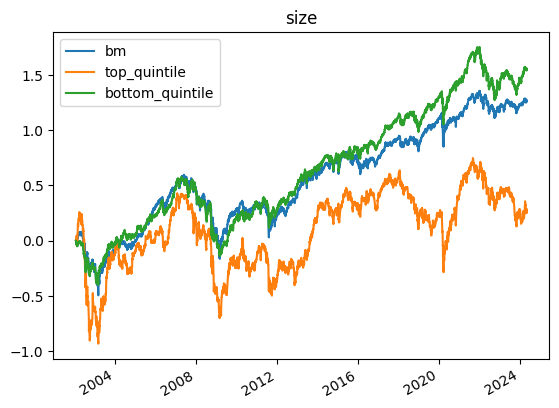

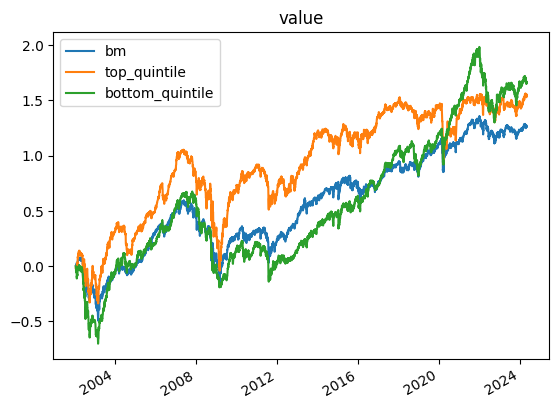

In [29]:
sim_dict = {}
for factor_theme, sim in top_quintile_return_series_dict.items():
    sim_dict[factor_theme] = pd.concat({
        'bm': data.bm_series,
        'top_quintile': top_quintile_return_series_dict[factor_theme],
        'bottom_quintile': bottom_quintile_return_series_dict[factor_theme],
    }, axis=1).dropna()

for factor_theme, df in sim_dict.items():
    np.log((1 + df).cumprod()).plot(title=factor_theme)

## 1. c) Factor analysis

- First, compute a factor-mix return series by averaging the returns of the top-quintile portfolio simulations that you have computed above. 

- Second, run an ordinary least squares regression of y on X, where y is your factor-mix serie and X contains i) a constant, ii) the SPI return series, and iii) the factor return series computed in 1.b).

- Use monthly returns.

- Print a summary table of the regression output

**(5 points)**

In [30]:
# Compute the factor-mix series
sim_factor_mix = pd.concat(top_quintile_return_series_dict, axis=1).mean(axis=1)

In [31]:
# Prepare the regression data
regression_data = pd.concat({
    'factor_mix': sim_factor_mix,
    'spi': bs.data.bm_series,
    **factor_return_series_dict,
}, axis=1)

# Drop NaN values
regression_data = regression_data.dropna()

# Aggregate from daily to monthly frequency (if needed)
regression_data = regression_data.resample('ME').apply(lambda x: (1 + x).prod() - 1)

# Define dependent and independent variables
y = regression_data['factor_mix']  # Dependent variable
X = regression_data.drop('factor_mix', axis=1)  # All other columns as independent variables

# Add constant term
X = sm.add_constant(X)

# Fit the regression model
model = sm.OLS(y, X)
results = model.fit()

# Display regression results
print("Regression Results: sim_factor_mix on constant, SPI, and factor return series")
print(results.summary())

Regression Results: sim_factor_mix on constant, SPI, and factor return series
                            OLS Regression Results                            
Dep. Variable:             factor_mix   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.830
Method:                 Least Squares   F-statistic:                     130.4
Date:                Sat, 16 May 2026   Prob (F-statistic):           1.98e-94
Time:                        00:26:05   Log-Likelihood:                 652.75
No. Observations:                 267   AIC:                            -1284.
Df Residuals:                     256   BIC:                            -1244.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------